In [ ]:
import kagglehub

try:
    dataset_path = kagglehub.dataset_download("jangedoo/utkface-new")
    print("Path to dataset files:", dataset_path)
except Exception as e:
    print(e)

/Users/kimilehmann/Library/Mobile Documents/com~apple~CloudDocs/Documents/HHN/SEB6/Vertiefung/Datenanalyse in Unternehmen/Projekt/AgeLens/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/kimilehmann/.cache/kagglehub/datasets/jangedoo/utkface-new/versions/1


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageStat
import random
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Flatten, MaxPooling2D, BatchNormalization, Dropout, RandomFlip, RandomRotation, RandomZoom
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split

In [ ]:
IMG_SIZE    = (200, 200)
AGE_MIN     = 1
AGE_MAX     = 100
BLUR_THRESH = 30.0
BRIGHT_MIN  = 30.0
BRIGHT_MAX  = 220.0

def is_blurry(img_gray, threshold=BLUR_THRESH):
    arr = np.array(img_gray, dtype=np.float32)
    laplacian = (
        arr[:-2,1:-1] + arr[2:,1:-1] + arr[1:-1,:-2] + arr[1:-1,2:]
        - 4 * arr[1:-1,1:-1]
    )
    return laplacian.var() < threshold

def is_bad_brightness(img_gray):
    mean = ImageStat.Stat(img_gray).mean[0]
    return mean < BRIGHT_MIN or mean > BRIGHT_MAX

def load_data(dataset_path):
    img_dir = os.path.join(dataset_path, "UTKFace")
    if not os.path.exists(img_dir):
        img_dir = dataset_path

    X, y = [], []
    skipped = {'age_range': 0, 'blurry': 0, 'brightness': 0, 'bad_filename': 0}

    files = [f for f in os.listdir(img_dir) if f.endswith('.jpg')]

    for filename in files:
        parts = filename.split('_')
        if len(parts) < 4:
            skipped['bad_filename'] += 1
            continue
        try:
            age = int(parts[0])
        except ValueError:
            skipped['bad_filename'] += 1
            continue

        if age < AGE_MIN or age > AGE_MAX:
            skipped['age_range'] += 1
            continue

        img_path = os.path.join(img_dir, filename)
        img_gray = Image.open(img_path).convert('L').resize(IMG_SIZE)

        if is_blurry(img_gray):
            skipped['blurry'] += 1
            continue
        if is_bad_brightness(img_gray):
            skipped['brightness'] += 1
            continue

        X.append(np.array(img_gray, dtype=np.float32))
        y.append(age)

    print(f"Geladen     : {len(X)} Bilder")
    print(f"Übersprungen: {skipped}")

    X = np.array(X).reshape(-1, IMG_SIZE[0], IMG_SIZE[1], 1)
    y = np.array(y, dtype=np.float32)
    return X, y

X, y = load_data(dataset_path)

Geladen     : 12364 Bilder
Übersprungen: {'age_range': 21, 'blurry': 11318, 'brightness': 2, 'bad_filename': 3}


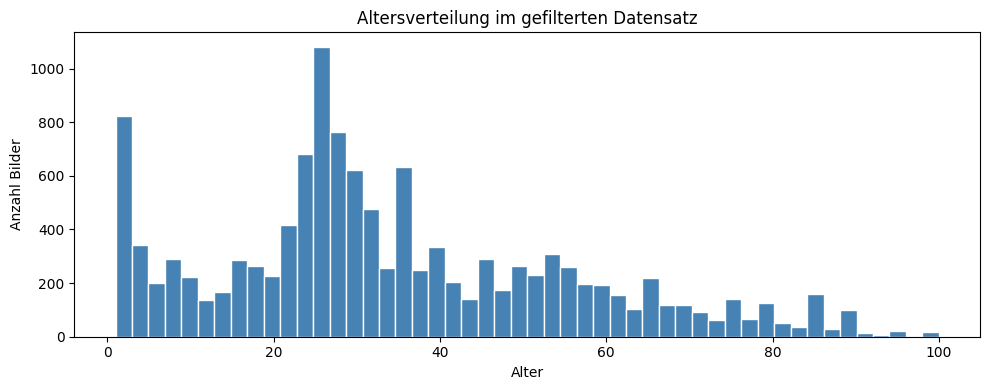

Alter: min=1, max=100, mean=34.1


In [4]:
plt.figure(figsize=(10, 4))
plt.hist(y, bins=50, color='steelblue', edgecolor='white')
plt.xlabel('Alter')
plt.ylabel('Anzahl Bilder')
plt.title('Altersverteilung im gefilterten Datensatz')
plt.tight_layout()
plt.show()

print(f"Alter: min={y.min():.0f}, max={y.max():.0f}, mean={y.mean():.1f}")

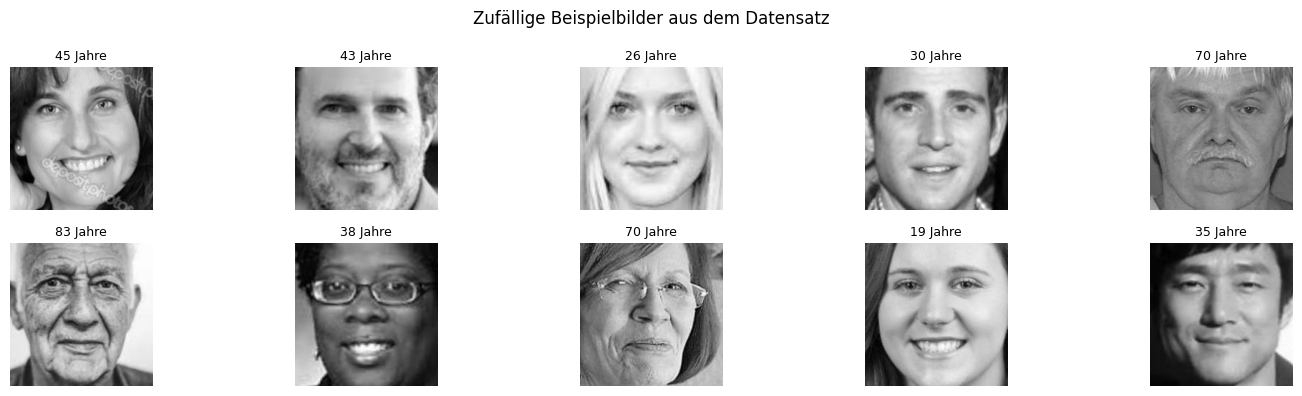

In [5]:
plt.figure(figsize=(15, 4))
indices = random.sample(range(len(X)), 10)
for i, idx in enumerate(indices):
    plt.subplot(2, 5, i+1)
    plt.imshow(X[idx].reshape(200, 200), cmap='gray')
    plt.title(f'{int(y[idx])} Jahre', fontsize=9)
    plt.axis('off')
plt.suptitle('Zufällige Beispielbilder aus dem Datensatz')
plt.tight_layout()
plt.show()

In [ ]:
X = X / 255.0

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_test : {X_test.shape}   y_test : {y_test.shape}")

X_train: (9891, 200, 200, 1)  y_train: (9891,)
X_test : (2473, 200, 200, 1)   y_test : (2473,)


In [ ]:
model = Sequential([
    # Augmentation
    RandomFlip("horizontal", input_shape=(200, 200, 1)),
    RandomRotation(0.1),
    RandomZoom(0.1),

    # Conv Block 1
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),         # → 100×100

    # Conv Block 2
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),         # → 50×50

    # Conv Block 3
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),         # → 25×25

    # Conv Block 4
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),         # → 12×12

    # Dense
    Flatten(),
    Dropout(0.4),
    Dense(256, activation='relu'),
    Dropout(0.3),

    # Output: Regression -> linear weil einzelne Zahl
    Dense(1, activation='linear', name='age')
])

model.compile(
    optimizer=Adam(learning_rate=0.0001), 
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 200, 200, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 200, 200, 1)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 200, 200, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 200, 200, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 200, 200, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100, 100, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 50, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 25, 25, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 25, 25, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ age (Dense)                     │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,827,457 (37.49 MB)

 Trainable params: 9,826,497 (37.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [8]:
callbacks = [
    EarlyStopping(
        monitor='val_mae',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'best_model.keras',
        monitor='val_mae',
        save_best_only=True,
        mode='min',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_mae',
        factor=0.5,
        patience=5,
        mode='min',
        verbose=1
    )
]

history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=64,
    validation_split=0.2,
    callbacks=callbacks
)

Epoch 1/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 448.0338 - mae: 16.3640
Epoch 1: val_mae improved from None to 35.18919, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
124/124 ━━━━━━━━━━━━━━━━━━━━ 163s 1s/step - loss: 327.7055 - mae: 13.9278 - val_loss: 1699.3864 - val_mae: 35.1892 - learning_rate: 1.0000e-04
Epoch 2/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 194.9834 - mae: 10.6277
Epoch 2: val_mae improved from 35.18919 to 20.33703, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
124/124 ━━━━━━━━━━━━━━━━━━━━ 158s 1s/step - loss: 193.7987 - mae: 10.5954 - val_loss: 694.2685 - val_mae: 20.3370 - learning_rate: 1.0000e-04
Epoch 3/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 171.0794 - mae: 10.0673
Epoch 3: val_mae improved from 20.33703 to 18.02352, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
124/124 ━━━━━━━━━━━━━━━━━━━━ 150s 1s/step - loss: 176

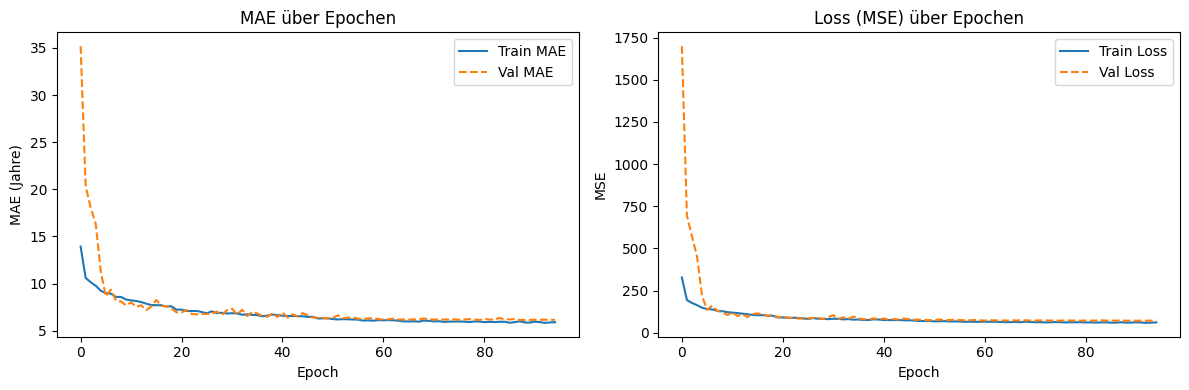

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# MAE
axes[0].plot(history.history['mae'],     label='Train MAE')
axes[0].plot(history.history['val_mae'], label='Val MAE', linestyle='--')
axes[0].set_title('MAE über Epochen')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MAE (Jahre)')
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss', linestyle='--')
axes[1].set_title('Loss (MSE) über Epochen')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE')
axes[1].legend()

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=120)
plt.show()

  MAE              : 5.85 Jahre
  Innerhalb ±5 J.  : 56.1%
  Innerhalb ±10 J. : 83.1%


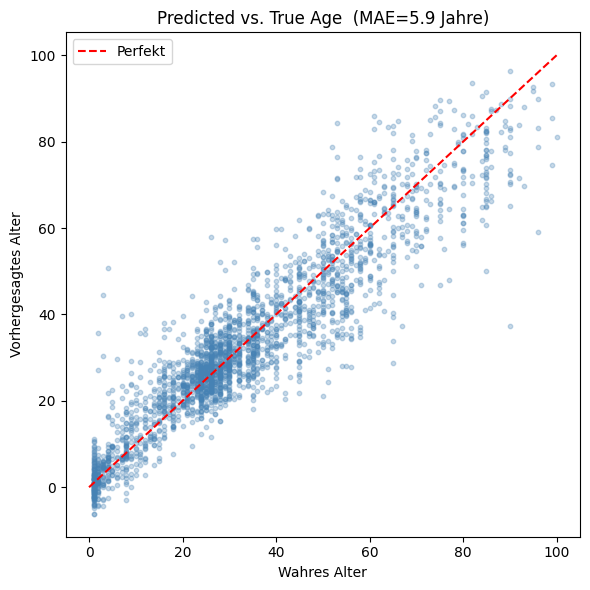

In [32]:
from keras.models import load_model
best_model = load_model('best_model.keras')

y_pred = best_model.predict(X_test, verbose=0).flatten()

mae        = np.mean(np.abs(y_pred - y_test))
within_5   = np.mean(np.abs(y_pred - y_test) <= 5)  * 100
within_10  = np.mean(np.abs(y_pred - y_test) <= 10) * 100

print(f'  MAE              : {mae:.2f} Jahre')
print(f'  Innerhalb ±5 J.  : {within_5:.1f}%')
print(f'  Innerhalb ±10 J. : {within_10:.1f}%')

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.3, s=10, color='steelblue')
plt.plot([0, 100], [0, 100], 'r--', label='Perfekt')
plt.xlabel('Wahres Alter')
plt.ylabel('Vorhergesagtes Alter')
plt.title(f'Predicted vs. True Age  (MAE={mae:.1f} Jahre)')
plt.legend()
plt.tight_layout()
plt.savefig('scatter_pred_vs_true.png', dpi=120)
plt.show()

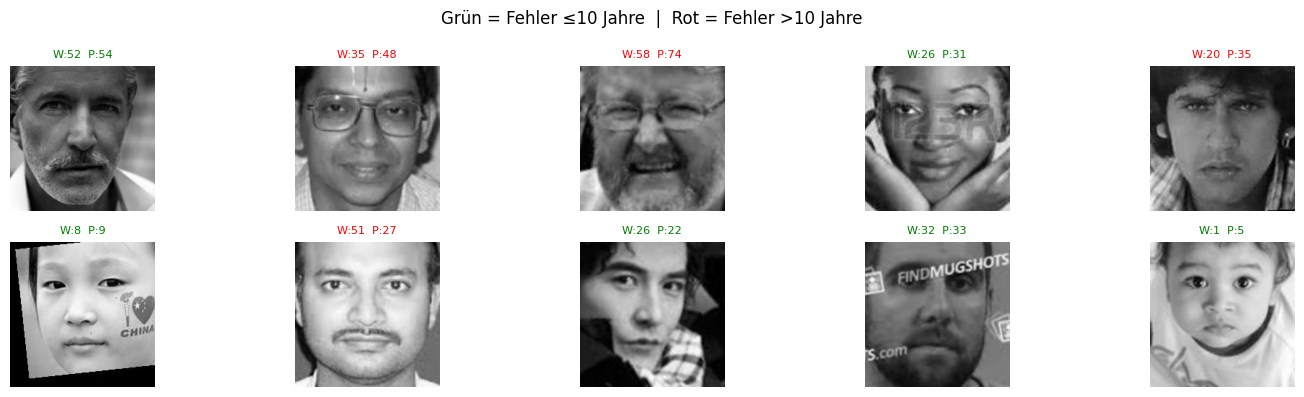

In [14]:
indices = random.sample(range(len(X_test)), 10)
sample_imgs = X_test[indices]
sample_true = y_test[indices]
sample_pred = best_model.predict(sample_imgs, verbose=0).flatten()

plt.figure(figsize=(15, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(sample_imgs[i].reshape(200, 200), cmap='gray')
    color = 'green' if abs(sample_pred[i] - sample_true[i]) <= 10 else 'red'
    plt.title(f'W:{int(sample_true[i])}  P:{sample_pred[i]:.0f}', fontsize=8, color=color)
    plt.axis('off')
plt.suptitle('Grün = Fehler ≤10 Jahre  |  Rot = Fehler >10 Jahre')
plt.tight_layout()
plt.show()

In [51]:
def predicted_age(img_path):
    img = Image.open(img_path).convert('L').resize(IMG_SIZE)
    img_array = np.array(img, dtype=np.float32) / 255.0
    img_array = img_array.reshape(1, IMG_SIZE[0], IMG_SIZE[1], 1)
    predicted_age = best_model.predict(img_array, verbose=0).flatten()[0]

    return round(predicted_age)

In [56]:
import os

img_path = "../Test/Test6.jpg"
print(f"Vorhergesagtes Alter für {os.path.basename(img_path)}: {predicted_age(img_path):.0f} Jahre")

Vorhergesagtes Alter für Test6.jpg: 51 Jahre
